https://chem.libretexts.org/Ancillary_Materials/Interactive_Applications/Jupyter_Notebooks/Particle_in_a_Finite_Potential_Box_(Python_Notebook)

Enter the value for Vo (in eV) = 1
Enter the value for L (in Angstroms) = 1


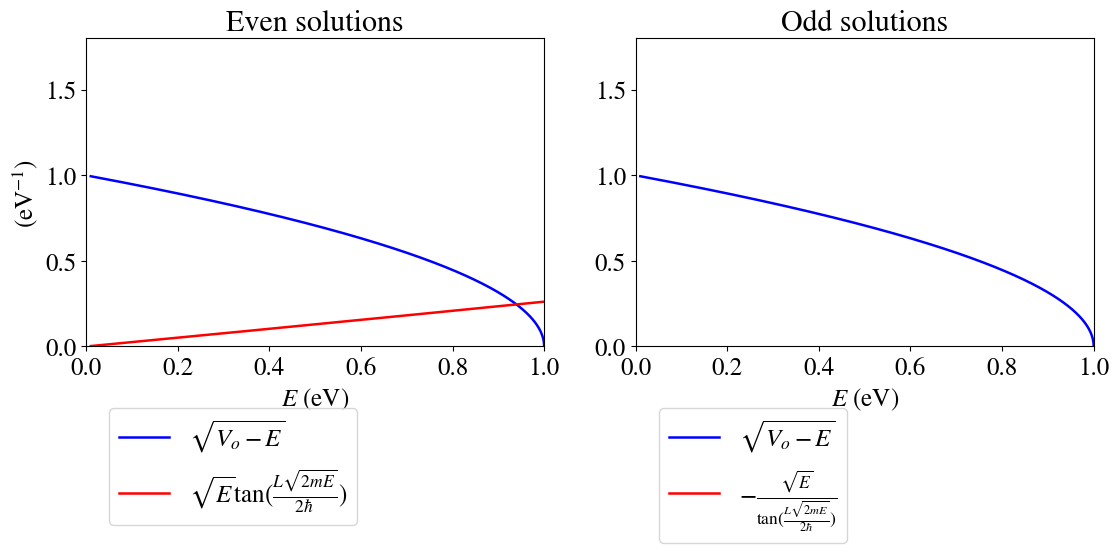

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Reading the input variables from the user
Vo = float(input("Enter the value for Vo (in eV) = "))
L =  float(input("Enter the value for L (in Angstroms) = "))

val = np.sqrt(2.0*9.10938356e-31*1.60217662e-19)*1e-10/(2.0*1.05457180013e-34) # equal to sqrt(2m*1eV)*1A/(2*hbar)

# Generating the graph
plt.rcParams.update({'font.size': 18, 'font.family': 'STIXGeneral', 'mathtext.fontset': 'stix'})
fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].axis([0.0,Vo,0.0,np.sqrt(Vo)*1.8])
axes[0].set_xlabel(r'$E$ (eV)')
axes[0].set_ylabel(r'(eV$^{-1}$)')
axes[0].set_title('Even solutions')
axes[1].axis([0.0,Vo,0.0,np.sqrt(Vo)*1.8])
axes[1].set_xlabel(r'$E$ (eV)')
axes[1].set_ylabel(r'')
axes[1].set_title('Odd solutions')
E = np.linspace(0.0, Vo, 10000)
num = int(round((L*np.sqrt(Vo)*val-np.pi/2.0)/np.pi))
# Removing discontinuity points
for n in range(10000):
    for m in range(num+2):
        if abs(E[n]-((2.0*float(m)+1.0)*np.pi/(2.0*L*val))**2)<0.01: E[n] = np.nan
        if abs(E[n]-(float(m)*np.pi/(L*val))**2)<0.01: E[n] = np.nan
# Plotting the curves and setting the labels
axes[0].plot(E, np.sqrt(Vo-E), label=r"$\sqrt{V_o-E}$", color="blue", linewidth=1.8)
axes[0].plot(E, np.sqrt(E)*np.tan(L*np.sqrt(E)*val), label=r"$\sqrt{E}\tan(\frac{L\sqrt{2mE}}{2\hbar})$", color="red", linewidth=1.8)
axes[1].plot(E, np.sqrt(Vo-E), label=r"$\sqrt{V_o-E}$", color="blue", linewidth=1.8)
axes[1].plot(E, -np.sqrt(E)/np.tan(L*np.sqrt(E)*val), label=r"$-\frac{\sqrt{E}}{\tan(\frac{L\sqrt{2mE}}{2\hbar})}$", color="red", linewidth=1.8)
# Chosing the positions of the legends
axes[0].legend(bbox_to_anchor=(0.05, -0.2), loc=2, borderaxespad=0.0)
axes[1].legend(bbox_to_anchor=(0.05, -0.2), loc=2, borderaxespad=0.0)

# Show the plots on the screen once the code reaches this point
plt.show()

In [ ]:
import numpy as np

print ("The allowed bounded energies are:")
# We want to find the values of E in which f_even and f_odd are zero
f_even = lambda E : np.sqrt(Vo-E)-np.sqrt(E)*np.tan(L*np.sqrt(E)*val)
f_odd = lambda E : np.sqrt(Vo-E)+np.sqrt(E)/np.tan(L*np.sqrt(E)*val)
E_old = 0.0
f_even_old = f_even(0.0)
f_odd_old = f_odd(0.0)
n = 1
E_vals = np.zeros(999)
# Here we loop from E = 0 to E = Vo seeking roots
for E in np.linspace(0.0, Vo, 200000):
    f_even_now = f_even(E)
    # If the difference is zero or if it changes sign then we might have passed through a root
    if f_even_now == 0.0 or f_even_now/f_even_old < 0.0:
        # If the old values of f are not close to zero, this means we didn't pass through a root but
        # through a discontinuity point
        if (abs(f_even_now)<1.0 and abs(f_even_old)<1.0):
            E_vals[n-1] = (E+E_old)/2.0
            print("State #%3d (Even wavefunction): %9.4f eV, %13.6g J" % (n,E_vals[n-1],E_vals[n-1]*1.60217662e-19))
            n += 1
    f_odd_now = f_odd(E)
    # If the difference is zero or if it changes sign then we might have passed through a root
    if f_odd_now == 0.0 or f_odd_now/f_odd_old < 0.0:
        # If the old values of f are not close to zero, this means we didn't pass through a root but
        # through a discontinuity point
        if (abs(f_odd_now)<1.0 and abs(f_odd_old)<1.0):
            E_vals[n-1] = (E+E_old)/2.0
            print("State #%3d  (Odd wavefunction): %9.4f eV, %13.6g J" % (n,E_vals[n-1],E_vals[n-1]*1.60217662e-19))
            n += 1
    E_old = E
    f_even_old = f_even_now
    f_odd_old = f_odd_now
nstates = n-1
print ("\nTHERE ARE %3d POSSIBLE BOUNDED ENERGIES" % nstates)

The allowed bounded energies are:


<ipython-input-6-2800903308>:6: RuntimeWarning: invalid value encountered in scalar divide
  f_odd = lambda E : np.sqrt(Vo-E)+np.sqrt(E)/np.tan(L*np.sqrt(E)*val)


State #  1 (Even wavefunction):    0.9396 eV,   1.50541e-19 J

THERE ARE   1 POSSIBLE BOUNDED ENERGIES


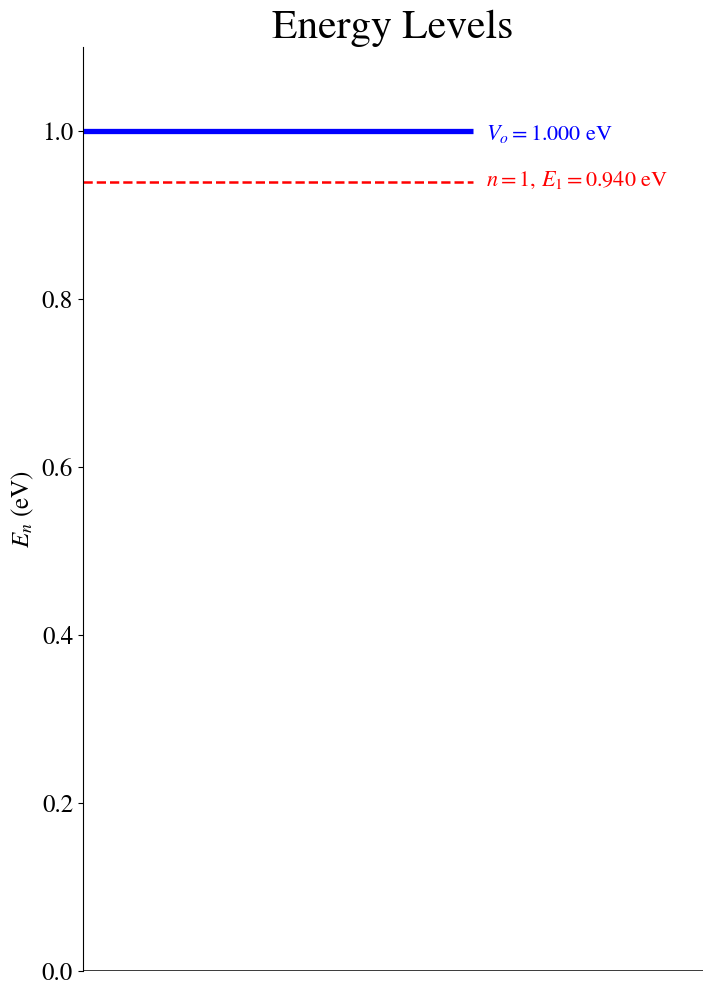

In [ ]:
import matplotlib.pyplot as plt

# Generating the energy diagram
fig, ax = plt.subplots(figsize=(8,12))
ax.spines['right'].set_color('none')
ax.yaxis.tick_left()
ax.spines['bottom'].set_color('none')
ax.axes.get_xaxis().set_visible(False)
ax.spines['top'].set_color('none')
ax.axis([0.0,10.0,0.0,1.1*Vo])
ax.set_ylabel(r'$E_n$ (eV)')
for n in range(1,nstates+1):
    str1="$n = "+str(n)+r"$, $E_"+str(n)+r" = %.3f$ eV"%(E_vals[n-1])
    ax.text(6.5, E_vals[n-1]-0.005*Vo, str1, fontsize=16, color="red")
    ax.hlines(E_vals[n-1], 0.0, 6.3, linewidth=1.8, linestyle='--', color="red")
str1="$V_o = %.3f$ eV"%(Vo)
ax.text(6.5, Vo-0.01*Vo, str1, fontsize=16, color="blue")
ax.hlines(Vo, 0.0, 6.3, linewidth=3.8, linestyle='-', color="blue")
ax.hlines(0.0, 0.0, 10.3, linewidth=1.8, linestyle='-', color="black")
plt.title("Energy Levels", fontsize=30)
plt.show()


The bound wavefunctions are:


<ipython-input-8-1087625836>:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(0.8, 1), loc=2, borderaxespad=0.)


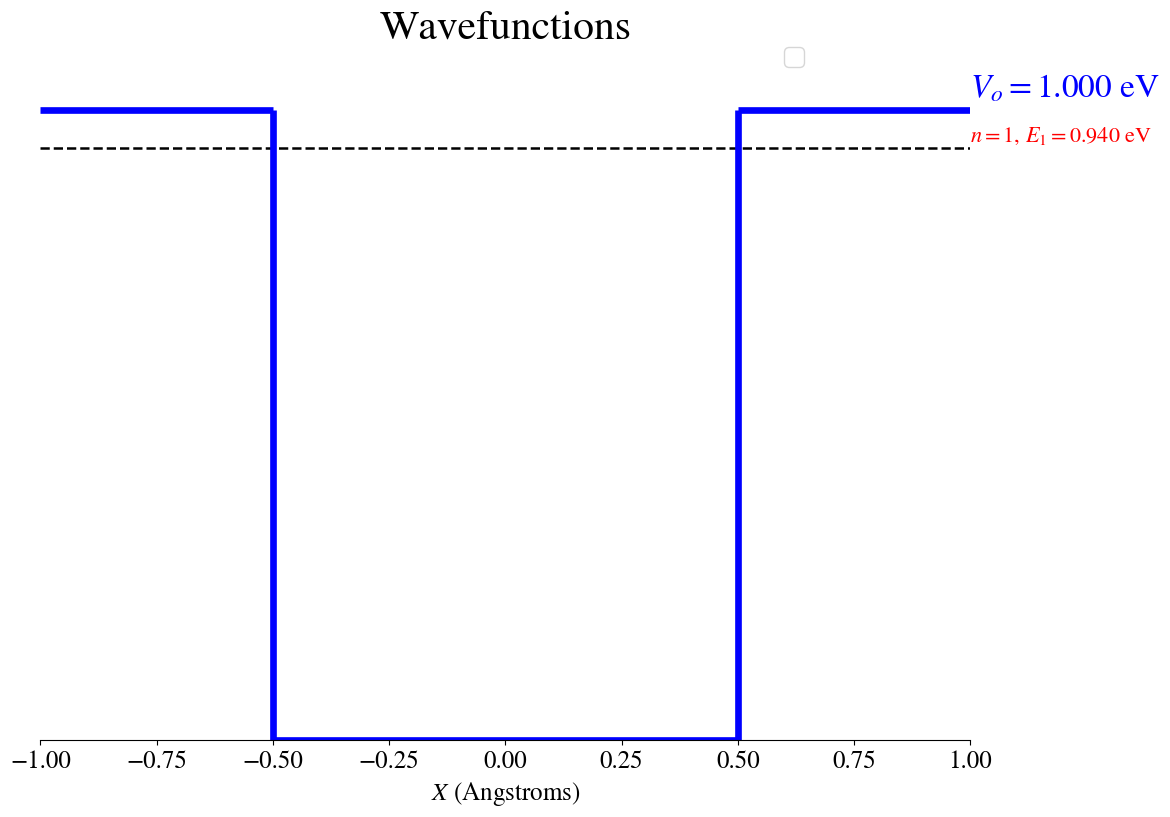

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print ("\nThe bound wavefunctions are:")
fig, ax = plt.subplots(figsize=(12,9))
ax.spines['right'].set_color('none')
ax.xaxis.tick_bottom()
ax.spines['left'].set_color('none')
ax.axes.get_yaxis().set_visible(False)
ax.spines['top'].set_color('none')
X_lef = np.linspace(-L, -L/2.0, 900,endpoint=True)
X_mid = np.linspace(-L/2.0, L/2.0, 900,endpoint=True)
X_rig = np.linspace(L/2.0, L, 900,endpoint=True)
ax.axis([-L,L,0.0,1.1*Vo])
ax.set_xlabel(r'$X$ (Angstroms)')
str1="$V_o = %.3f$ eV"%(Vo)
ax.text(2.0*L/2.0, 1.02*Vo, str1, fontsize=24, color="blue")
# Defining the maximum amplitude of the wavefunction
if (nstates > 1):
    amp = np.sqrt((E_vals[1]-E_vals[0])/1.5)
else:
    amp = np.sqrt((Vo-E_vals[0])/1.5)
# Plotting the wavefunctions
for n in range(1,nstates+1):
    ax.hlines(E_vals[n-1], -L, L, linewidth=1.8, linestyle='--', color="black")
    str1="$n = "+str(n)+r"$, $E_"+str(n)+r" = %.3f$ eV"%(E_vals[n-1])
    ax.text(2.0*L/2.0, E_vals[n-1]+0.01*Vo, str1, fontsize=16, color="red")
    k = 2.0*np.sqrt(E_vals[n-1])*val
    a0 = 2.0*np.sqrt(Vo-E_vals[n-1])*val
    # Plotting odd wavefunction
    if (n%2==0):
        ax.plot(X_lef,E_vals[n-1]-amp*np.exp(a0*L/2.0)*np.sin(k*L/2.0)*np.exp(a0*X_lef), color="red", label="", linewidth=2.8)
        ax.plot(X_mid,E_vals[n-1]+amp*np.sin(k*X_mid), color="red", label="", linewidth=2.8)
        ax.plot(X_rig,E_vals[n-1]+amp*np.exp(a0*L/2.0)*np.sin(k*L/2.0)*np.exp(-a0*X_rig), color="red", label="", linewidth=2.8)
    # Plotting even wavefunction
    else:
        ax.plot(X_lef,E_vals[n-1]+amp*np.exp(a0*L/2.0)*np.cos(k*L/2.0)*np.exp(a0*X_lef), color="red", label="", linewidth=2.8)
        ax.plot(X_mid,E_vals[n-1]+amp*np.cos(k*X_mid), color="red", label="", linewidth=2.8)
        ax.plot(X_rig,E_vals[n-1]+amp*np.exp(a0*L/2.0)*np.cos(k*L/2.0)*np.exp(-a0*X_rig), color="red", label="", linewidth=2.8)
ax.margins(0.00)
ax.vlines(-L/2.0, 0.0, Vo, linewidth=4.8, color="blue")
ax.vlines(L/2.0, 0.0, Vo, linewidth=4.8, color="blue")
ax.hlines(0.0, -L/2.0, L/2.0, linewidth=4.8, color="blue")
ax.hlines(Vo, -L, -L/2.0, linewidth=4.8, color="blue")
ax.hlines(Vo, L/2.0, L, linewidth=4.8, color="blue")
plt.title('Wavefunctions', fontsize=30)
plt.legend(bbox_to_anchor=(0.8, 1), loc=2, borderaxespad=0.)
plt.show()


The bound Probability Densities are shown below 
with the areas shaded in green showing the regions where the particle can tunnel outside the box


<ipython-input-9-2555414413>:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(0.8, 1), loc=2, borderaxespad=0.)


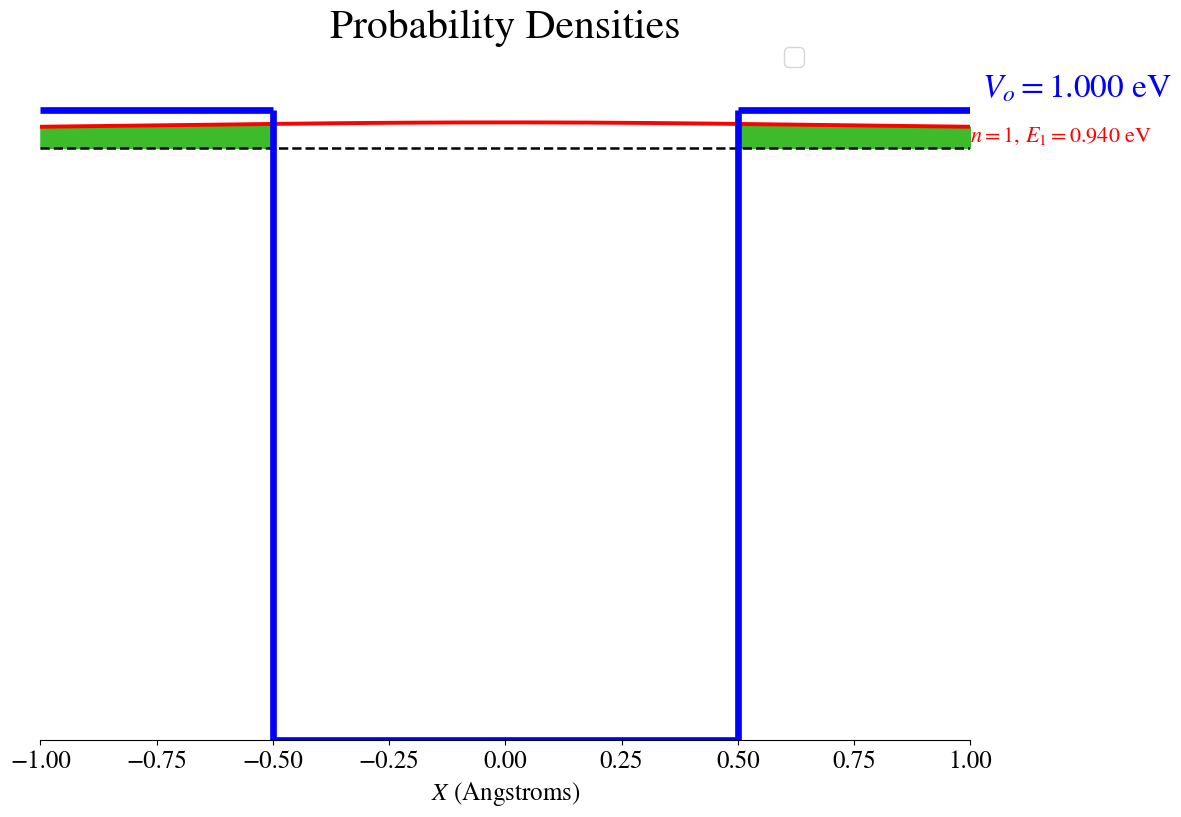

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print ("\nThe bound Probability Densities are shown below \nwith the areas shaded in green showing the regions where the particle can tunnel outside the box")
fig, ax = plt.subplots(figsize=(12,9))
ax.spines['right'].set_color('none')
ax.xaxis.tick_bottom()
ax.spines['left'].set_color('none')
ax.axes.get_yaxis().set_visible(False)
ax.spines['top'].set_color('none')
X_lef = np.linspace(-L, -L/2.0, 900,endpoint=True)
X_mid = np.linspace(-L/2.0, L/2.0, 900,endpoint=True)
X_rig = np.linspace(L/2.0, L, 900,endpoint=True)
ax.axis([-L,L,0.0,1.1*Vo])
ax.set_xlabel(r'$X$ (Angstroms)')
str1="$V_o = %.3f$ eV"%(Vo)
ax.text(2.05*L/2.0, 1.02*Vo, str1, fontsize=24, color="blue")
# Defining the maximum amplitude of the probability density
if (nstates > 1):
    amp = (E_vals[1]-E_vals[0])/1.5
else:
    amp = (Vo-E_vals[0])/1.5
# Plotting the probability densities
for n in range(1,nstates+1):
    ax.hlines(E_vals[n-1], -L, L, linewidth=1.8, linestyle='--', color="black")
    str1="$n = "+str(n)+r"$, $E_"+str(n)+r" = %.3f$ eV"%(E_vals[n-1])
    ax.text(2.0*L/2.0, E_vals[n-1]+0.01*Vo, str1, fontsize=16, color="red")
    k = 2.0*np.sqrt(E_vals[n-1])*val
    a0 = 2.0*np.sqrt(Vo-E_vals[n-1])*val
    # Plotting odd probability densities
    if (n%2==0):
        Y_lef = E_vals[n-1]+amp*(np.exp(a0*L/2.0)*np.sin(k*L/2.0)*np.exp(a0*X_lef))**2
        ax.plot(X_lef,Y_lef, color="red", label="", linewidth=2.8)
        ax.fill_between(X_lef, E_vals[n-1], Y_lef, color="#3dbb2a")
        ax.plot(X_mid,E_vals[n-1]+amp*(np.sin(k*X_mid))**2, color="red", label="", linewidth=2.8)
        Y_rig = E_vals[n-1]+amp*(np.exp(a0*L/2.0)*np.sin(k*L/2.0)*np.exp(-a0*X_rig))**2
        ax.plot(X_rig,Y_rig, color="red", label="", linewidth=2.8)
        ax.fill_between(X_rig, E_vals[n-1], Y_rig, color="#3dbb2a")
    # Plotting even probability densities
    else:
        Y_lef = E_vals[n-1]+amp*(np.exp(a0*L/2.0)*np.cos(k*L/2.0)*np.exp(a0*X_lef))**2
        ax.plot(X_lef,Y_lef, color="red", label="", linewidth=2.8)
        ax.fill_between(X_lef, E_vals[n-1], Y_lef, color="#3dbb2a")
        ax.plot(X_mid,E_vals[n-1]+amp*(np.cos(k*X_mid))**2, color="red", label="", linewidth=2.8)
        Y_rig = E_vals[n-1]+amp*(np.exp(a0*L/2.0)*np.cos(k*L/2.0)*np.exp(-a0*X_rig))**2
        ax.plot(X_rig,Y_rig, color="red", label="", linewidth=2.8)
        ax.fill_between(X_rig, E_vals[n-1], Y_rig, color="#3dbb2a")
ax.margins(0.00)
ax.vlines(-L/2.0, 0.0, Vo, linewidth=4.8, color="blue")
ax.vlines(L/2.0, 0.0, Vo, linewidth=4.8, color="blue")
ax.hlines(0.0, -L/2.0, L/2.0, linewidth=4.8, color="blue")
ax.hlines(Vo, -L, -L/2.0, linewidth=4.8, color="blue")
ax.hlines(Vo, L/2.0, L, linewidth=4.8, color="blue")
plt.title('Probability Densities', fontsize=30)
plt.legend(bbox_to_anchor=(0.8, 1), loc=2, borderaxespad=0.)
plt.show()

In [ ]:
import numpy as np

print ("\nThe tunneling probabilities are:")
for n in range(1,nstates+1):
    k = 2.0*np.sqrt(E_vals[n-1])*val
    a0 = 2.0*np.sqrt(Vo-E_vals[n-1])*val
    # For odd solution
    if (n%2==0):
        C = 1.0
        D = np.exp(a0*L/2.0)*np.sin(k*L/2.0)*C
        prob = D*D*2.0*k*np.exp(-a0*L)/(B*B*a0*(k*L-np.sin(k*L))+D*D*2.0*k*np.exp(-a0*L))
    # For even solution
    else:
        B = 1.0
        D = np.exp(a0*L/2.0)*np.cos(k*L/2.0)*B
        prob = D*D*2.0*k*np.exp(-a0*L)/(B*B*a0*(k*L+np.sin(k*L))+D*D*2.0*k*np.exp(-a0*L))
    print("State #%3d tunneling probability = %5.2f%%" % (n,100*prob))


The tunneling probabilities are:
State #  1 tunneling probability = 88.40%
